# DATATHON 2026 — Revenue Forecast 

In [1]:
# ═══════════════════════════════════════════
# 0. SETUP
# ═══════════════════════════════════════════
import numpy as np
import pandas as pd
import os, warnings
warnings.filterwarnings('ignore')

import lightgbm as lgb
import shap
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import seaborn as sns
import matplotlib.pyplot as plt
from lunardate import LunarDate
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

SEED = 42
np.random.seed(SEED)

# Portable path: uu tien CWD la repo root (VS Code), fallback len thu muc cha
_cwd = os.path.abspath("")
DATA_PATH = (
    os.path.join(_cwd, "data", "processed")
    if os.path.isdir(os.path.join(_cwd, "data"))
    else os.path.normpath(os.path.join(_cwd, "..", "data", "processed"))
)
TRAIN_START = pd.Timestamp('2012-07-04')
TRAIN_END   = pd.Timestamp('2022-12-31')
TEST_START  = pd.Timestamp('2023-01-01')
TEST_END    = pd.Timestamp('2024-07-01')

def load(fname, **kw):
    path = os.path.join(DATA_PATH, fname)
    if not os.path.exists(path):
        print(f'⚠️  Không tìm thấy {fname} — bỏ qua')
        return None
    return pd.read_csv(path, **kw)

print(f'Train: {TRAIN_START.date()} → {TRAIN_END.date()}')
print(f'Test : {TEST_START.date()} → {TEST_END.date()}')

Train: 2012-07-04 → 2022-12-31
Test : 2023-01-01 → 2024-07-01


In [2]:
# ═══════════════════════════════════════════
# 1. LOAD DATA
# ═══════════════════════════════════════════
sales      = load('sales.csv',             parse_dates=['Date'])
sample_sub = load('sample_submission.csv', parse_dates=['Date'])
assert sales['Date'].max() < sample_sub['Date'].min(), 'LEAKAGE: train/test overlap!'

web_traffic = load('web_traffic.csv',  parse_dates=['date'])
orders      = load('orders.csv',       parse_dates=['order_date'])
order_items = load('order_items.csv')
promotions  = load('promotions.csv',   parse_dates=['start_date', 'end_date'])
inventory   = load('inventory.csv',    parse_dates=['snapshot_date'])
returns     = load('returns.csv',      parse_dates=['return_date'])
reviews     = load('reviews.csv',      parse_dates=['review_date'])

print(f'Sales: {sales.shape} | {sales["Date"].min().date()} → {sales["Date"].max().date()}')

Sales: (3833, 3) | 2012-07-04 → 2022-12-31


In [3]:
# ═══════════════════════════════════════════
# 2. DAILY AGGREGATES FROM EXTERNAL SOURCES
# ═══════════════════════════════════════════

# ── 2A. Web Traffic ──────────────────────────────────────────────────
traffic_daily = None
if web_traffic is not None:
    wt = web_traffic.rename(columns={'date': 'Date'})
    agg = {c: 'sum'  for c in ['sessions', 'unique_visitors', 'page_views'] if c in wt.columns}
    agg.update({c: 'mean' for c in ['bounce_rate', 'avg_session_duration_sec'] if c in wt.columns})
    traffic_daily = wt.groupby('Date').agg(agg).reset_index()
    traffic_daily.columns = ['Date'] + [f'wt_{c}' for c in traffic_daily.columns[1:]]
    if 'wt_sessions' in traffic_daily and 'wt_unique_visitors' in traffic_daily:
        traffic_daily['wt_uv_ratio'] = traffic_daily['wt_unique_visitors'] / (traffic_daily['wt_sessions'] + 1)

# ── 2B. Orders ──────────────────────────────────────────────────────
orders_daily = None
if orders is not None:
    ord_ = orders.rename(columns={'order_date': 'Date'})
    cnt  = ord_.groupby('Date').size().rename('ord_count')
    cancelled = (ord_.groupby('Date')['order_status'].apply(lambda x: (x == 'cancelled').mean()).rename('ord_cancel_rate')
                 if 'order_status' in ord_.columns else pd.Series(dtype=float, name='ord_cancel_rate'))
    mobile = (ord_.groupby('Date')['device_type'].apply(lambda x: (x == 'mobile').mean()).rename('ord_mobile_rate')
              if 'device_type' in ord_.columns else pd.Series(dtype=float, name='ord_mobile_rate'))
    orders_daily = pd.concat([cnt, cancelled, mobile], axis=1).reset_index()

# ── 2C. Order Items ─────────────────────────────────────────────────
items_daily = None
if order_items is not None and orders is not None:
    oi = order_items.merge(orders[['order_id','order_date']].rename(columns={'order_date':'Date'}), on='order_id', how='left')
    if all(c in oi.columns for c in ['discount_amount','quantity','unit_price']):
        oi['item_discount_rate'] = oi['discount_amount'] / (oi['quantity'] * oi['unit_price'] + 1)
    if 'promo_id' in oi.columns:
        oi['has_promo'] = oi['promo_id'].notna().astype(int)
    agg = {c: f for c, f in [('item_discount_rate','mean'), ('has_promo','mean'), ('quantity','sum')]
           if c in oi.columns}
    if agg:
        items_daily = oi.groupby('Date').agg(agg).reset_index()
        items_daily.columns = ['Date'] + [f'oi_{c}' for c in items_daily.columns[1:]]

# ── 2D. Promotions ──────────────────────────────────────────────────
promo_daily = None
if promotions is not None:
    records = [{'Date': d, 'discount_value': r.get('discount_value', 0),
                'stackable': r.get('stackable_flag', 0)}
               for _, r in promotions.iterrows()
               for d in pd.date_range(r['start_date'], r['end_date'])]
    promo_df  = pd.DataFrame(records)
    promo_agg = promo_df.groupby('Date').agg(
        promo_count=('discount_value','count'),
        promo_max_discount=('discount_value','max'),
        promo_sum_discount=('discount_value','sum'),
    ).reset_index()
    full_range = pd.DataFrame({'Date': pd.date_range(TRAIN_START, TEST_END)})
    promo_daily = full_range.merge(promo_agg, on='Date', how='left').fillna(0)
    promo_daily['has_promo_today'] = (promo_daily['promo_count'] > 0).astype(int)

# ── 2E. Inventory ───────────────────────────────────────────────────
inv_daily = None
if inventory is not None:
    inv_agg = inventory.groupby('snapshot_date').agg(
        inv_days_supply=('days_of_supply','mean'),
        inv_fill_rate=('fill_rate','mean'),
    ).reset_index().rename(columns={'snapshot_date':'Date'})
    inv_daily = pd.DataFrame({'Date': pd.date_range(TRAIN_START, TEST_END)}).merge(inv_agg, on='Date', how='left')
    inv_daily[['inv_days_supply','inv_fill_rate']] = inv_daily[['inv_days_supply','inv_fill_rate']].ffill().bfill()

# ── 2F. Returns ───────────────────────────────────────────────
ret_daily = None
if returns is not None:
    ret_agg = returns.groupby('return_date').agg(
        ret_quantity=('return_quantity', 'sum'),
        ret_refund  =('refund_amount',   'sum'),
    ).reset_index().rename(columns={'return_date': 'Date'})
    _full = pd.DataFrame({'Date': pd.date_range(TRAIN_START, TEST_END)})
    ret_daily = _full.merge(ret_agg, on='Date', how='left').fillna(0)

# ── 2G. Reviews ──────────────────────────────────────────────
rvw_daily = None
if reviews is not None:
    rvw_agg = reviews.groupby('review_date').agg(
        rvw_avg_rating=('rating',     'mean'),
        rvw_count     =('review_id',  'count'),
    ).reset_index().rename(columns={'review_date': 'Date'})
    _full = pd.DataFrame({'Date': pd.date_range(TRAIN_START, TEST_END)})
    rvw_daily = _full.merge(rvw_agg, on='Date', how='left')
    rvw_daily['rvw_avg_rating'] = rvw_daily['rvw_avg_rating'].ffill().fillna(3.0)
    rvw_daily['rvw_count']      = rvw_daily['rvw_count'].fillna(0)

print('External aggregates done')

External aggregates done


In [4]:
# ═══════════════════════════════════════════
# 3. MERGE MASTER FRAME
# ═══════════════════════════════════════════
master = sales.copy()
for name, ext_df in [('web_traffic', traffic_daily), ('orders', orders_daily),
                     ('order_items', items_daily), ('promotions', promo_daily),
                     ('inventory', inv_daily), ('returns', ret_daily), ('reviews', rvw_daily)]:
    if ext_df is not None:
        master = master.merge(ext_df, on='Date', how='left')
print(f'Master: {master.shape}')

Master: (3833, 25)


Top 15 tương quan với log_revenue:
Revenue                  0.922
COGS                     0.903
ord_count                0.860
oi_quantity              0.844
rvw_count                0.586
inv_days_supply         -0.496
ret_quantity             0.454
ret_refund               0.442
wt_sessions              0.339
wt_unique_visitors       0.336
wt_page_views            0.317
inv_fill_rate           -0.286
oi_item_discount_rate   -0.169
promo_max_discount      -0.150
promo_sum_discount      -0.145


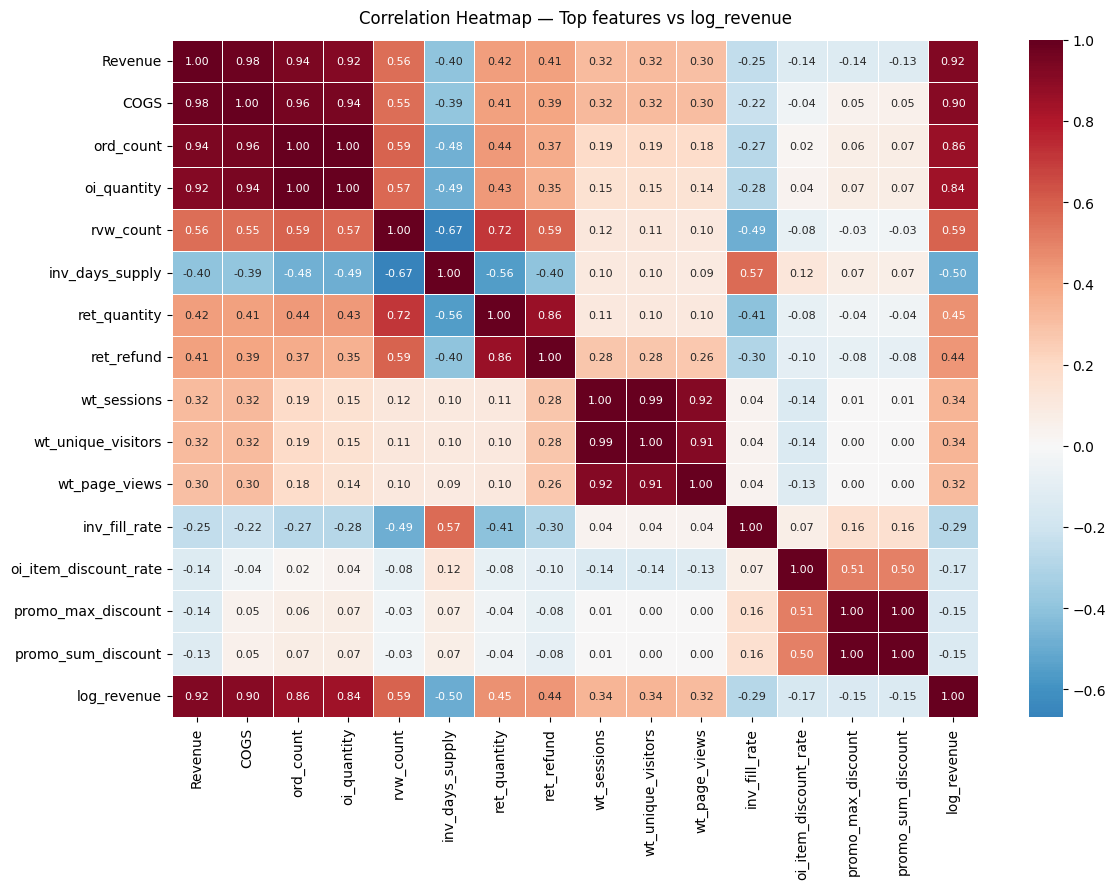

In [5]:
# ═══════════════════════════════════════════
# 4. CORRELATION HEATMAP → chọn feature engineering
# ═══════════════════════════════════════════
corr_df = master.copy()
corr_df['log_revenue'] = np.log1p(corr_df['Revenue'])

# Lấy các numeric cols có tương quan với log_revenue
num_cols = corr_df.select_dtypes(include=[np.number]).columns.tolist()
corr_with_target = corr_df[num_cols].corr()['log_revenue'].drop('log_revenue').sort_values(key=abs, ascending=False)

print('Top 15 tương quan với log_revenue:')
print(corr_with_target.head(15).round(3).to_string())

# Heatmap ma trận tương quan (top 15 features)
top_corr_cols = corr_with_target.head(15).index.tolist() + ['log_revenue']
fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(
    corr_df[top_corr_cols].corr(),
    annot=True, fmt='.2f', cmap='RdBu_r', center=0,
    linewidths=0.5, ax=ax, annot_kws={'size': 8}
)
ax.set_title('Correlation Heatmap — Top features vs log_revenue', fontsize=12, pad=12)
plt.tight_layout()
plt.show()

In [6]:
# ═══════════════════════════════════════════
# 5. FEATURE ENGINEERING

tet_map        = {y: pd.Timestamp(LunarDate(y, 1, 1).toSolarDate()) for y in range(2012, 2027)}
tet_dates_list = sorted(tet_map.values())
MEGA_SALE_DAYS = {(9,9),(10,10),(11,11),(12,12)}
mega_dates     = sorted([pd.Timestamp(year=y, month=m, day=d)
                         for y in range(2012, 2026) for m,d in MEGA_SALE_DAYS])
VN_FIXED_HOLIDAYS = {(1,1),(4,30),(5,1),(9,2)}

def days_to_next(date, events):
    future = [e for e in events if e >= date]
    return (future[0] - date).days if future else 999

def days_since_last(date, events):
    past = [e for e in events if e <= date]
    return (date - past[-1]).days if past else 999


def build_features(df, target='log_revenue'):
    df = df.sort_values('Date').reset_index(drop=True)

    # 1. Calendar
    df['dayofweek']      = df['Date'].dt.dayofweek
    df['month']          = df['Date'].dt.month
    df['day']            = df['Date'].dt.day
    df['quarter']        = df['Date'].dt.quarter
    df['is_weekend']     = (df['dayofweek'] >= 5).astype(int)
    df['is_month_end']   = df['Date'].dt.is_month_end.astype(int)
    df['is_vn_holiday']  = df['Date'].apply(lambda d: int((d.month, d.day) in VN_FIXED_HOLIDAYS))
    df['day_in_month_norm'] = df['day'] / df['Date'].dt.days_in_month

    # 2. Trend
    df['year_idx']    = (df['Date'] - TRAIN_START).dt.days / 365.25
    df['year_idx_sq'] = df['year_idx'] ** 2

    # 3. Event proximity
    df['days_to_tet']       = df['Date'].apply(lambda d: days_to_next(d, tet_dates_list)).clip(0, 60)
    df['days_since_tet']    = df['Date'].apply(lambda d: days_since_last(d, tet_dates_list)).clip(0, 60)
    df['is_pre_tet']        = (df['days_to_tet'] <= 14).astype(int)
    df['is_post_tet']       = (df['days_since_tet'] <= 7).astype(int)
    df['days_to_next_mega'] = df['Date'].apply(lambda d: days_to_next(d, mega_dates)).clip(0, 90)
    df['days_since_mega']   = df['Date'].apply(lambda d: days_since_last(d, mega_dates)).clip(0, 14)
    df['is_mega_sale']      = (df['days_to_next_mega'] == 0).astype(int)

    # 4. Lag 
    for lag in [1, 7, 364, 365]:                    
        df[f'rev_lag_{lag}'] = df[target].shift(lag)

    # 5. Rolling statistics (giảm bớt)
    s = df[target].shift(1)
    for w in [7, 30]:                                  # bỏ 14, 90
        df[f'rev_roll_mean_{w}'] = s.rolling(w).mean()
    df['rev_momentum_7_30'] = df['rev_roll_mean_7'] - df['rev_roll_mean_30']

    # 6. Fourier
    doy = df['Date'].dt.dayofyear
    for k in range(1, 4):
        df[f'sin_year_{k}'] = np.sin(2 * np.pi * k * doy / 365.25)
        df[f'cos_year_{k}'] = np.cos(2 * np.pi * k * doy / 365.25)

    # 7. Web traffic (lag1 + roll7 )
    for col in [c for c in df.columns if c.startswith('wt_') and not c.endswith(('_lag1','_roll7'))]:
        df[f'{col}_lag1']  = df[col].shift(1)
        df[f'{col}_roll7'] = df[col].shift(1).rolling(7).mean()

    # 8. Orders (lag1 + roll7)
    for col in [c for c in df.columns if c.startswith('ord_') and not c.endswith(('_lag1','_roll7'))]:
        df[f'{col}_lag1']  = df[col].shift(1)
        df[f'{col}_roll7'] = df[col].shift(1).rolling(7).mean()

    # 9. Order Items (lag1 + roll7) — oi_ dung du lieu cung ngay, phai lag de tranh lookahead
    for col in [c for c in df.columns if c.startswith('oi_') and not c.endswith(('_lag1','_roll7'))]:
        df[f'{col}_lag1']  = df[col].shift(1)
        df[f'{col}_roll7'] = df[col].shift(1).rolling(7).mean()

    # 10. Returns (lag1 + roll7)
    for col in [c for c in df.columns if c.startswith('ret_') and not c.endswith(('_lag1','_roll7'))]:
        df[f'{col}_lag1']  = df[col].shift(1)
        df[f'{col}_roll7'] = df[col].shift(1).rolling(7).mean()

    # 11. Reviews (lag1 + roll7)
    for col in [c for c in df.columns if c.startswith('rvw_') and not c.endswith(('_lag1','_roll7'))]:
        df[f'{col}_lag1']  = df[col].shift(1)
        df[f'{col}_roll7'] = df[col].shift(1).rolling(7).mean()

    # 12. Promotions
    if 'promo_count' in df.columns:
        df['promo_intensity']  = df['promo_sum_discount'].fillna(0).clip(0, 500)
        df['promo_lag1_count'] = df['promo_count'].fillna(0).shift(1)
        df['promo_roll7']      = df['promo_count'].fillna(0).shift(1).rolling(7).mean()

    # 13. Interaction 
    if 'has_promo_today' in df.columns:
        df['weekend_x_promo'] = df['is_weekend'] * df['has_promo_today'].fillna(0)
        df['pretet_x_promo']  = df['is_pre_tet']  * df['has_promo_today'].fillna(0)

    # Dedup columns — phòng _lag1_lag1 nếu gọi lại trên df đã có derived cols
    df = df.loc[:, ~df.columns.duplicated()]

    return df

print('build_features() v3 ready')

build_features() v3 ready


In [7]:
# ═══════════════════════════════════════════
# 6. BUILD TRAINING DATASET
# ═══════════════════════════════════════════
df_full = master.copy()
df_full['log_revenue'] = np.log1p(df_full['Revenue'])
df_full['log_cogs']    = np.log1p(df_full['COGS'])

# Fill NaN external TRUOC khi tinh lag/roll:
# neu fill sau thi lag1/roll7 da duoc tinh tu data co NaN, fill khong co tac dung
ext_fill_cols = [c for c in df_full.columns
                 if c.startswith(('wt_','ord_','oi_','promo_','inv_'))]
for col in ext_fill_cols:
    if df_full[col].isna().any():
        df_full[col] = df_full[col].ffill().fillna(df_full[col].median())

df_full = build_features(df_full, target='log_revenue')

EXCLUDE        = {'Date','Revenue','COGS','log_revenue','log_cogs'}
# Re-enable short lags: rev_lag_1/7 va rolling means rat quan trong cho
# short-term forecasting; forecast loop se tinh chinh xac tu known_log
SHORT_LAG_COLS = set()
# Loai raw same-day external cols (wt_, ord_, oi_, ret_, rvw_) — fix lookahead bias
WT_RAW_COLS  = {c for c in df_full.columns
                if c.startswith('wt_')  and not c.endswith(('_lag1','_roll7'))}
ORD_RAW_COLS = {c for c in df_full.columns
                if c.startswith('ord_') and not c.endswith(('_lag1','_roll7'))}
OI_RAW_COLS  = {c for c in df_full.columns
                if c.startswith('oi_')  and not c.endswith(('_lag1','_roll7'))}
RET_RAW_COLS = {c for c in df_full.columns
                if c.startswith('ret_') and not c.endswith(('_lag1','_roll7'))}
RVW_RAW_COLS = {c for c in df_full.columns
                if c.startswith('rvw_') and not c.endswith(('_lag1','_roll7'))}
FEATURE_COLS = [c for c in df_full.columns
                if c not in EXCLUDE and c not in SHORT_LAG_COLS
                and c not in WT_RAW_COLS  and c not in ORD_RAW_COLS
                and c not in OI_RAW_COLS  and c not in RET_RAW_COLS
                and c not in RVW_RAW_COLS]
df_train     = df_full.dropna(subset=FEATURE_COLS).copy()
X            = df_train[FEATURE_COLS].values
y_log_rev    = df_train['log_revenue'].values

#  COGS ratio 
_cogs_train = df_train[df_train['Revenue'] > 0].copy()
COGS_RATIO  = float((_cogs_train['COGS'] / _cogs_train['Revenue']).clip(0.01, 0.99).median())
print(f'COGS_RATIO = {COGS_RATIO:.4f}')

for lag_col in ['rev_lag_364', 'rev_lag_365']:
    if lag_col in df_full.columns:
        nan_before = df_full[lag_col].isna().sum()
        nan_after  = df_train[lag_col].isna().sum()
        print(f'{lag_col}: NaN trước dropna={nan_before}, sau dropna={nan_after}')

print(f'Train rows : {len(df_train)}')
print(f'Features   : {len(FEATURE_COLS)}')

COGS_RATIO = 0.8264
rev_lag_364: NaN trước dropna=364, sau dropna=0
rev_lag_365: NaN trước dropna=365, sau dropna=0
Train rows : 3468
Features   : 73


In [8]:
# ═══════════════════════════════════════════
# 7. BASELINE RIDGE
# ═══════════════════════════════════════════
split = int(len(X) * 0.8)
bl = Pipeline([('sc', StandardScaler()), ('r', Ridge(alpha=1.0, random_state=SEED))])
bl.fit(X[:split], y_log_rev[:split])
y_bl = np.expm1(bl.predict(X[split:]))
y_bt = np.expm1(y_log_rev[split:])
rmse_bl = np.sqrt(mean_squared_error(y_bt, y_bl))
print(f'Baseline Ridge | MAE={mean_absolute_error(y_bt, y_bl):,.0f} | RMSE={rmse_bl:,.0f} | R²={r2_score(y_bt, y_bl):.4f}')


Baseline Ridge | MAE=771,678 | RMSE=1,073,252 | R²=0.5846


In [9]:
# ═══════════════════════════════════════════
# 8. CROSS-VALIDATION 
BASE_PARAMS = {
    'objective':               'huber',
    'alpha':                   0.5,
    'n_estimators':            3000,
    'learning_rate':           0.02,
    'num_leaves':              47,       
    'max_depth':               6,         
    'min_child_samples':       50,        
    'min_gain_to_split':       0.02,    
    'subsample':               0.75,      
    'subsample_freq':          1,
    'colsample_bytree':        0.75,      
    'feature_fraction_bynode': 0.75,
    'reg_alpha':               0.3,      
    'reg_lambda':              4.0,       
    'random_state':            SEED,
    'n_jobs':                  -1,
    'verbose':                 -1,
}

tscv = TimeSeriesSplit(n_splits=5)
cv_mae, cv_rmse, best_iters_rev = [], [], []

for fold, (tr_idx, va_idx) in enumerate(tscv.split(X)):
    cb = [lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)]

    m_rev = lgb.LGBMRegressor(**BASE_PARAMS)
    m_rev.fit(X[tr_idx], y_log_rev[tr_idx], eval_set=[(X[va_idx], y_log_rev[va_idx])], callbacks=cb)
    best_iters_rev.append(m_rev.best_iteration_)

    pred = np.expm1(m_rev.predict(X[va_idx]))
    true = np.expm1(y_log_rev[va_idx])
    mae  = mean_absolute_error(true, pred)
    rmse = np.sqrt(mean_squared_error(true, pred))
    r2   = r2_score(true, pred)
    cv_mae.append(mae)
    cv_rmse.append(rmse)
    print(f'Fold {fold+1} | MAE={mae:>10,.0f} | RMSE={rmse:>10,.0f} | R²={r2:.4f} | iter={m_rev.best_iteration_}')

best_n_rev  = max(int(np.mean(best_iters_rev)),  50)
print(f'\nCV MAE : {np.mean(cv_mae):,.0f} ± {np.std(cv_mae):,.0f}')
print(f'CV RMSE: {np.mean(cv_rmse):,.0f} ± {np.std(cv_rmse):,.0f}')
print(f'best_n_rev={best_n_rev}')


Fold 1 | MAE= 1,072,967 | RMSE= 1,618,349 | R²=0.7070 | iter=556
Fold 2 | MAE=   814,046 | RMSE= 1,212,920 | R²=0.8036 | iter=247
Fold 3 | MAE=   825,475 | RMSE= 1,147,126 | R²=0.8308 | iter=756
Fold 4 | MAE=   583,269 | RMSE=   852,283 | R²=0.7572 | iter=555
Fold 5 | MAE=   561,101 | RMSE=   776,094 | R²=0.7520 | iter=251

CV MAE : 771,372 ± 187,246
CV RMSE: 1,121,354 ± 299,218
best_n_rev=473


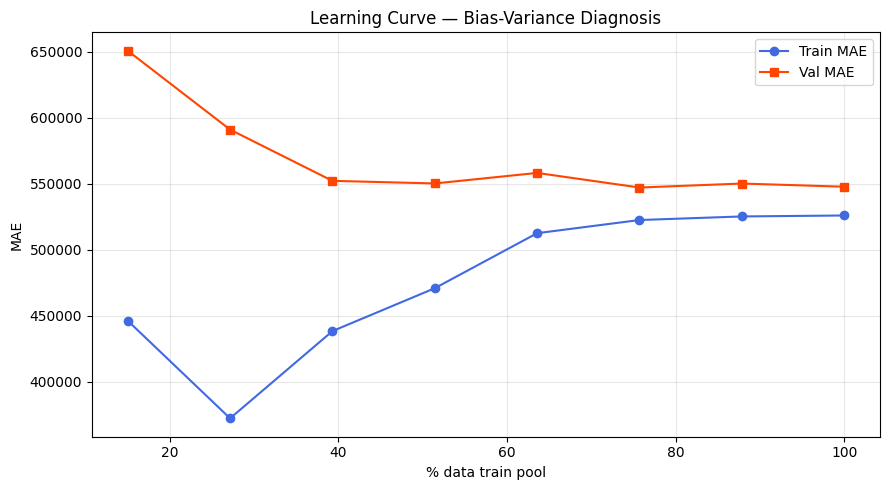

Train MAE: 525,904 | Val MAE: 547,701 | Gap: +21,797 (+4.1%)
 Bias-Variance ổn


In [10]:
# ═══════════════════════════════════════════
# 9. LEARNING CURVE
# ═══════════════════════════════════════════
tr_pool, val_idx_lc = list(tscv.split(X))[-1]
train_fracs = np.linspace(0.15, 1.0, 8)
train_errs, val_errs = [], []

for frac in train_fracs:
    n   = max(int(len(tr_pool) * frac), 60)
    m   = lgb.LGBMRegressor(**{**BASE_PARAMS, 'n_estimators': best_n_rev})
    m.fit(X[tr_pool[-n:]], y_log_rev[tr_pool[-n:]], callbacks=[lgb.log_evaluation(-1)])
    train_errs.append(mean_absolute_error(np.expm1(y_log_rev[tr_pool[-n:]]), np.expm1(m.predict(X[tr_pool[-n:]]))))
    val_errs.append(mean_absolute_error(np.expm1(y_log_rev[val_idx_lc]), np.expm1(m.predict(X[val_idx_lc]))))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(train_fracs*100, train_errs, 'o-', color='royalblue', label='Train MAE')
ax.plot(train_fracs*100, val_errs,   's-', color='orangered',  label='Val MAE')
ax.set_xlabel('% data train pool'); ax.set_ylabel('MAE')
ax.set_title('Learning Curve — Bias-Variance Diagnosis'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

gap       = val_errs[-1] - train_errs[-1]
gap_ratio = gap / train_errs[-1] if train_errs[-1] > 0 else 0
print(f'Train MAE: {train_errs[-1]:,.0f} | Val MAE: {val_errs[-1]:,.0f} | Gap: {gap:+,.0f} ({gap_ratio:+.1%})')
if gap_ratio > 0.30:
    print('⚠  Overfit → tăng reg_lambda / min_child_samples thêm')
else:
    print(' Bias-Variance ổn')

In [11]:
# ═══════════════════════════════════════════
# 10. OPTUNA HYPERPARAMETER TUNING
def objective(trial):
    params = {
        'objective':               'huber',
        'alpha':                    trial.suggest_float('alpha', 0.3, 0.7),
        'n_estimators':            3000,
        'learning_rate':            trial.suggest_float('learning_rate', 0.01, 0.05, log=True),
        'num_leaves':               trial.suggest_int('num_leaves', 31, 63),
        'max_depth':                trial.suggest_int('max_depth', 4, 7),
        'min_child_samples':        trial.suggest_int('min_child_samples', 40, 100),
        'min_gain_to_split':        trial.suggest_float('min_gain_to_split', 0.01, 0.1),
        'subsample':                trial.suggest_float('subsample', 0.6, 0.85),
        'subsample_freq':           1,
        'colsample_bytree':         trial.suggest_float('colsample_bytree', 0.6, 0.85),
        'feature_fraction_bynode':  trial.suggest_float('feature_fraction_bynode', 0.6, 0.85),
        'reg_alpha':                trial.suggest_float('reg_alpha', 0.1, 5.0, log=True),
        'reg_lambda':               trial.suggest_float('reg_lambda', 2.0, 15.0, log=True),
        'random_state': SEED, 'n_jobs': -1, 'verbose': -1,
    }
    all_splits = list(TimeSeriesSplit(n_splits=5).split(X))
    scores = []
    for tr, va in all_splits[-3:]:
        m = lgb.LGBMRegressor(**params)
        m.fit(X[tr], y_log_rev[tr], eval_set=[(X[va], y_log_rev[va])],
              callbacks=[lgb.early_stopping(40, verbose=False), lgb.log_evaluation(-1)])
        scores.append(mean_absolute_error(np.expm1(y_log_rev[va]), np.expm1(m.predict(X[va]))))
    return np.mean(scores)

study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective, n_trials=50, show_progress_bar=True)

BEST_PARAMS = {**BASE_PARAMS, **study.best_params}
print(f'Best CV MAE: {study.best_value:,.0f}')
print('Best params:', study.best_params)

# ── Recalibrate best_n_rev với BEST_PARAMS
_recal_iters = []
for tr_idx, va_idx in list(TimeSeriesSplit(n_splits=5).split(X))[-3:]:
    _m = lgb.LGBMRegressor(**{**BEST_PARAMS, 'n_estimators': 3000})
    _m.fit(X[tr_idx], y_log_rev[tr_idx],
           eval_set=[(X[va_idx], y_log_rev[va_idx])],
           callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)])
    _recal_iters.append(_m.best_iteration_)
best_n_rev = max(int(np.mean(_recal_iters)), 50)
BEST_PARAMS['n_estimators'] = best_n_rev
print(f'best_n_rev (recalibrated) = {best_n_rev}')

  0%|          | 0/50 [00:00<?, ?it/s]

Best CV MAE: 645,065
Best params: {'alpha': 0.6879639408647977, 'learning_rate': 0.03818145165896871, 'num_leaves': 38, 'max_depth': 4, 'min_child_samples': 51, 'min_gain_to_split': 0.0373818018663584, 'subsample': 0.7311891079080595, 'colsample_bytree': 0.7079862546605289, 'feature_fraction_bynode': 0.6728072850495105, 'reg_alpha': 1.0952662748632551, 'reg_lambda': 2.6490836340777935}
best_n_rev (recalibrated) = 474


In [12]:
# ═══════════════════════════════════════════
# 11. FINAL MODEL
# ═══════════════════════════════════════════
tscv = TimeSeriesSplit(n_splits=5)

final_rev = lgb.LGBMRegressor(**BEST_PARAMS)
final_rev.fit(X, y_log_rev, callbacks=[lgb.log_evaluation(-1)])

# Bias correction từ trung bình 3 fold cuối
_last_tr_idx, _last_va_idx = list(tscv.split(X))[-1]
bias_list = []
for tr_idx, va_idx in list(tscv.split(X))[-3:]:
    tmp = lgb.LGBMRegressor(**BEST_PARAMS)
    tmp.fit(X[tr_idx], y_log_rev[tr_idx], callbacks=[lgb.log_evaluation(-1)])
    _vp = np.expm1(tmp.predict(X[va_idx]))
    _vt = np.expm1(y_log_rev[va_idx])
    bias_list.append(float((_vt - _vp).mean()))

# Validation trên fold cuối (dùng _last_va_idx đã lưu ở trên)
val_pred = np.expm1(final_rev.predict(X[_last_va_idx]))
val_true = np.expm1(y_log_rev[_last_va_idx])
# Lưu val_dates để dùng lại ở cell SHAP plot (tránh lệch index)
val_dates_final = df_train.iloc[_last_va_idx]['Date']

# Dung fold cuoi (gan nhat voi test period) — tranh bias fold cu keo lech
# bias_list co the rat khac nhau theo thoi gian, fold cuoi la estimate tot nhat
BIAS_CORRECTION = float(bias_list[-1])

val_mae  = mean_absolute_error(val_true, val_pred)
val_rmse = np.sqrt(mean_squared_error(val_true, val_pred))
val_r2   = r2_score(val_true, val_pred)

print(f'BIAS_CORRECTION per fold: {[f"{b:+,.0f}" for b in bias_list]}')
print(f'Val | MAE={val_mae:,.0f} | RMSE={val_rmse:,.0f} | R²={val_r2:.4f}')
print(f'BIAS_CORRECTION = {BIAS_CORRECTION:+,.0f}')
print(' Retrain done')


BIAS_CORRECTION per fold: ['-271,010', '+182,667', '+170,048']
Val | MAE=407,274 | RMSE=562,771 | R²=0.8696
BIAS_CORRECTION = +170,048
 Retrain done


In [13]:
# ═══════════════════════════════════════════
# 12. RECURSIVE FORECASTING
# ═══════════════════════════════════════════
test_dates_df = sample_sub[['Date']].assign(Revenue=np.nan, COGS=np.nan)
master_full   = pd.concat([master, test_dates_df]).sort_values('Date').reset_index(drop=True)

ext_cols = [c for c in master_full.columns if c.startswith(('wt_','ord_','oi_','ret_','rvw_'))]
for col in ext_cols:
    fill_val = master_full.loc[master_full['Date'] <= TRAIN_END, col].dropna().tail(90).mean()
    master_full[col] = master_full[col].ffill().fillna(fill_val)

if promo_daily is not None:
    promo_cols = [c for c in promo_daily.columns if c != 'Date']
    master_full = master_full.drop(columns=[c for c in promo_cols if c in master_full.columns], errors='ignore')
    master_full = master_full.merge(promo_daily, on='Date', how='left').fillna({c: 0 for c in promo_cols})

master_full['log_revenue'] = np.log1p(master_full['Revenue'].fillna(0))
master_full['log_cogs']    = np.log1p(master_full['COGS'].fillna(0))

# Pre-compute static features (calendar, Tet, Mega, Fourier) một lần — tránh .apply() lặp lại
def build_static_features(df):
    df = df.sort_values('Date').reset_index(drop=True)
    df['dayofweek']         = df['Date'].dt.dayofweek
    df['month']             = df['Date'].dt.month
    df['day']               = df['Date'].dt.day
    df['quarter']           = df['Date'].dt.quarter
    df['is_weekend']        = (df['dayofweek'] >= 5).astype(int)
    df['is_month_end']      = df['Date'].dt.is_month_end.astype(int)
    df['is_vn_holiday']     = df['Date'].apply(lambda d: int((d.month, d.day) in VN_FIXED_HOLIDAYS))
    df['day_in_month_norm'] = df['day'] / df['Date'].dt.days_in_month
    df['year_idx']          = (df['Date'] - TRAIN_START).dt.days / 365.25
    df['year_idx_sq']       = df['year_idx'] ** 2
    df['days_to_tet']       = df['Date'].apply(lambda d: days_to_next(d, tet_dates_list)).clip(0, 60)
    df['days_since_tet']    = df['Date'].apply(lambda d: days_since_last(d, tet_dates_list)).clip(0, 60)
    df['is_pre_tet']        = (df['days_to_tet'] <= 14).astype(int)
    df['is_post_tet']       = (df['days_since_tet'] <= 7).astype(int)
    df['days_to_next_mega'] = df['Date'].apply(lambda d: days_to_next(d, mega_dates)).clip(0, 90)
    df['days_since_mega']   = df['Date'].apply(lambda d: days_since_last(d, mega_dates)).clip(0, 14)
    df['is_mega_sale']      = (df['days_to_next_mega'] == 0).astype(int)
    doy = df['Date'].dt.dayofyear
    for k in range(1, 4):
        df[f'sin_year_{k}'] = np.sin(2 * np.pi * k * doy / 365.25)
        df[f'cos_year_{k}'] = np.cos(2 * np.pi * k * doy / 365.25)
    if 'has_promo_today' in df.columns:
        df['weekend_x_promo'] = df['is_weekend'] * df['has_promo_today'].fillna(0)
        df['pretet_x_promo']  = df['is_pre_tet']  * df['has_promo_today'].fillna(0)
    if 'promo_count' in df.columns:
        df['promo_intensity']  = df['promo_sum_discount'].fillna(0).clip(0, 500)
        df['promo_lag1_count'] = df['promo_count'].fillna(0).shift(1)
        df['promo_roll7']      = df['promo_count'].fillna(0).shift(1).rolling(7).mean()
    return df

master_full = build_static_features(master_full)

# Pre-build known_log ngoai loop — O(1) lookup, update sau moi buoc predict
known_log = master_full.set_index('Date')['log_revenue'].copy()

predictions = []

for date in sample_sub['Date'].tolist():
    row_i = master_full.index[master_full['Date'] == date][0]
    row   = master_full.loc[[row_i]].copy()

    # Lag features: all lags including short-term (rev_lag_1/7 now in FEATURE_COLS)
    for lag in [1, 7, 364, 365]:
        if f'rev_lag_{lag}' in FEATURE_COLS:
            row[f'rev_lag_{lag}'] = known_log.get(date - pd.Timedelta(days=lag), np.nan)

    # Short-term rolling stats (critical for capturing recent momentum)
    if any(c in FEATURE_COLS for c in ['rev_roll_mean_7','rev_roll_mean_30','rev_momentum_7_30']):
        hist_log = known_log[known_log.index < date].dropna().sort_index()
        if 'rev_roll_mean_7' in FEATURE_COLS:
            row['rev_roll_mean_7']  = hist_log.tail(7).mean()  if len(hist_log) >= 1 else np.nan
        if 'rev_roll_mean_30' in FEATURE_COLS:
            row['rev_roll_mean_30'] = hist_log.tail(30).mean() if len(hist_log) >= 1 else np.nan
        if 'rev_momentum_7_30' in FEATURE_COLS:
            _r7  = hist_log.tail(7).mean()  if len(hist_log) >= 1 else np.nan
            _r30 = hist_log.tail(30).mean() if len(hist_log) >= 1 else np.nan
            row['rev_momentum_7_30'] = _r7 - _r30

    # External features lag+roll: wt_, ord_, oi_, ret_, rvw_
    for col in [c for c in master_full.columns
                if c.startswith(('wt_','ord_','oi_','ret_','rvw_')) and not c.endswith(('_lag1','_roll7'))]:
        prev = master_full.loc[master_full['Date'] < date, col].dropna()
        if f'{col}_lag1' in FEATURE_COLS:
            row[f'{col}_lag1']  = prev.iloc[-1] if len(prev) > 0 else 0.0
        if f'{col}_roll7' in FEATURE_COLS:
            row[f'{col}_roll7'] = prev.tail(7).mean() if len(prev) > 0 else 0.0

    feat    = row[FEATURE_COLS].copy()
    log_rev = float(final_rev.predict(feat)[0])
    rev     = max(np.expm1(log_rev) + BIAS_CORRECTION, 0.0)
    cogs    = rev * COGS_RATIO
    predictions.append({'Date': date, 'Revenue': rev, 'COGS': cogs})

    # Cap nhat known_log va master_full cho recursive forecasting
    known_log[date] = log_rev
    master_full.loc[row_i, 'log_revenue'] = log_rev

pred_df = pd.DataFrame(predictions)
print(f'Forecast done: {len(pred_df)} ngày')
print(f'Revenue  min/max: {pred_df["Revenue"].min():,.0f} / {pred_df["Revenue"].max():,.0f}')

Forecast done: 548 ngày
Revenue  min/max: 1,328,864 / 6,215,598


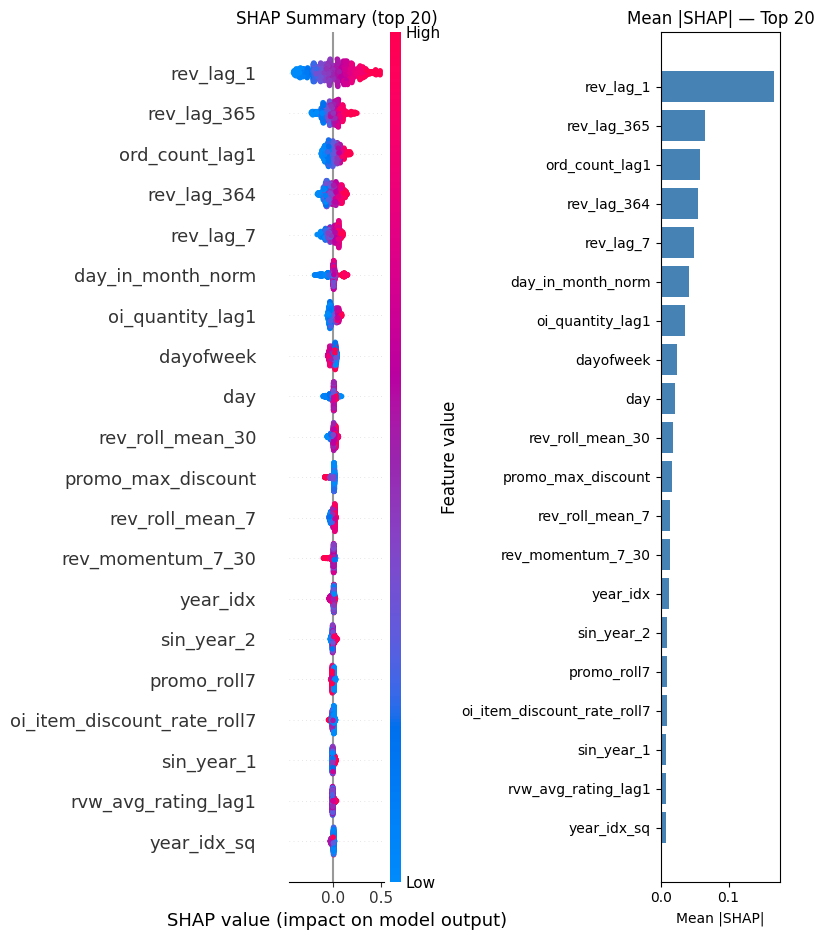

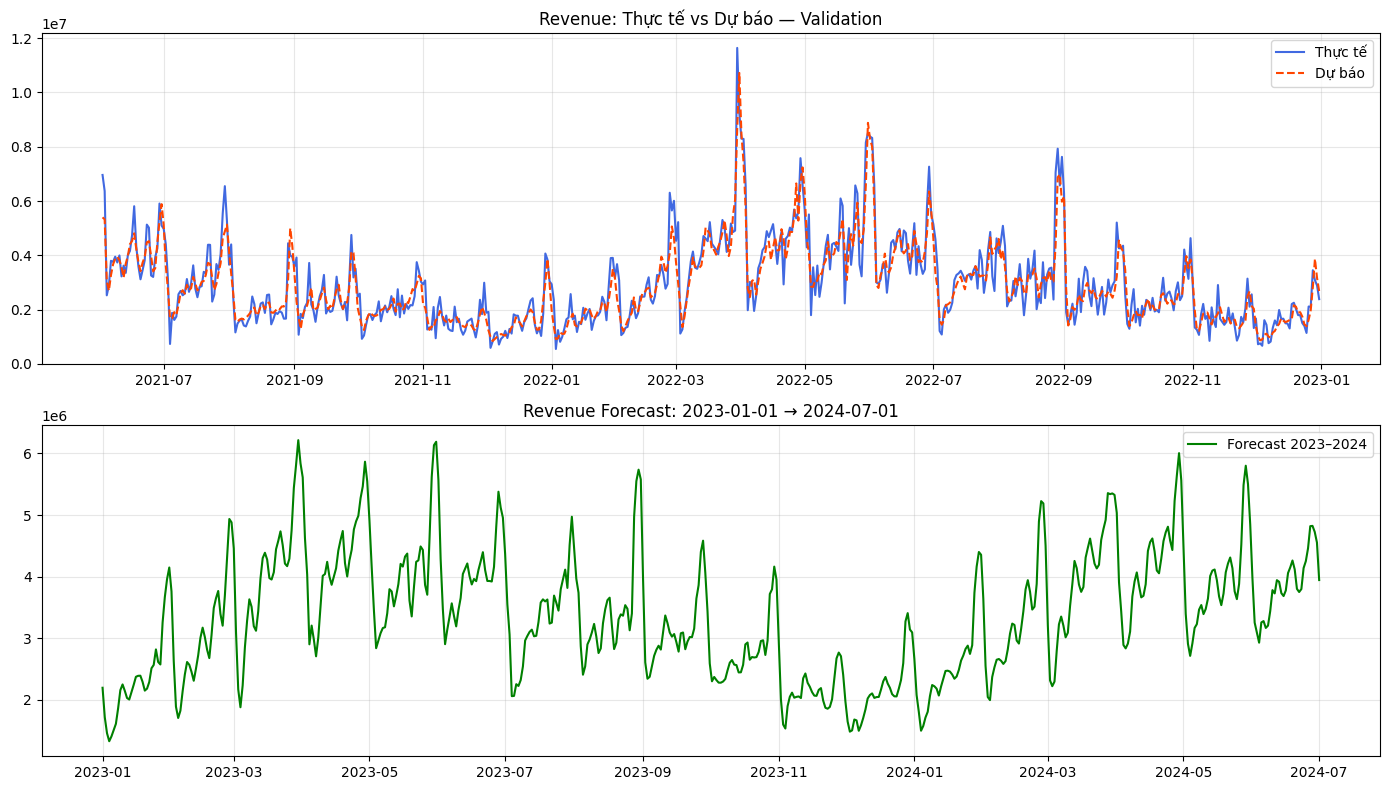

In [14]:
# ═══════════════════════════════════════════
# 13. SHAP + VALIDATION PLOTS
# ═══════════════════════════════════════════
sample_idx = np.sort(np.random.choice(len(df_train), min(1000, len(df_train)), replace=False))
explainer  = shap.TreeExplainer(final_rev)
shap_vals  = explainer(df_train.iloc[sample_idx][FEATURE_COLS])

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
plt.sca(axes[0])
shap.summary_plot(shap_vals, df_train.iloc[sample_idx][FEATURE_COLS], show=False, max_display=20)
axes[0].set_title('SHAP Summary (top 20)')

mean_shap = pd.Series(np.abs(shap_vals.values).mean(0), index=FEATURE_COLS).sort_values(ascending=False)
top20 = mean_shap.head(20)
axes[1].barh(top20.index[::-1], top20.values[::-1], color='steelblue')
axes[1].set_title('Mean |SHAP| — Top 20')
axes[1].set_xlabel('Mean |SHAP|')
plt.tight_layout()
plt.show()


# Dùng val_dates_final đã được lưu ở cell 11 (khớp với val_pred/val_true)
val_dates = val_dates_final
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
axes[0].plot(val_dates.values, val_true, label='Thực tế', color='royalblue', lw=1.5)
axes[0].plot(val_dates.values, val_pred, label='Dự báo',  color='orangered',  lw=1.5, ls='--')
axes[0].set_title('Revenue: Thực tế vs Dự báo — Validation'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(pred_df['Date'], pred_df['Revenue'], color='green', lw=1.5, label='Forecast 2023–2024')
axes[1].set_title('Revenue Forecast: 2023-01-01 → 2024-07-01'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Phân tích SHAP — Các Yếu Tố Dẫn Động Doanh Thu

**Phương pháp:** SHAP TreeExplainer trên 1,000 mẫu ngẫu nhiên từ tập train.
Biểu đồ bên trái thể hiện hướng tác động (đỏ = giá trị feature cao, xanh = thấp);
biểu đồ bên phải xếp hạng theo Trung bình |SHAP| — mức độ quan trọng trung bình tuyệt đối.

---

#### Top 20 Features 

**1. `rev_lag_1` — Doanh thu ngày hôm qua** 

Feature quan trọng nhất với biên độ vượt trội. Giá trị cao (đỏ) → SHAP dương mạnh,
giá trị thấp (xanh) → SHAP âm. Điều này xác nhận **đà tăng trưởng ngắn hạn** là tín hiệu
dự báo mạnh nhất: một ngày bán tốt có xu hướng kéo theo ngày tiếp theo tốt hơn mức nền.

**2. `rev_lag_365` & `rev_lag_364` — Doanh thu cùng kỳ năm ngoái**

Hai feature này nằm ở vị trí #2 và #4, xác nhận **tính mùa vụ theo năm là cực kỳ mạnh**.
Cùng kỳ năm ngoái là mốc tham chiếu đáng tin cậy — mô hình học được rằng
chu kỳ mùa vụ lặp lại nhất quán qua các năm (Tết, đỉnh cuối năm, đáy tháng 2).

**3. `ord_count_lag1` — Số đơn hàng ngày hôm qua** *(#3)*

Tín hiệu nhu cầu trực tiếp: số đơn hôm qua phản ánh sức mua của thị trường và có tương
quan cao với doanh thu hôm nay. Feature này độc lập với doanh thu trễ, cung cấp
thông tin bổ sung về **khối lượng giao dịch**.

**4. `rev_lag_7` — Doanh thu 7 ngày trước** *(#5)*

Bắt được **chu kỳ trong tuần** — cùng thứ tuần trước là mốc tham chiếu tốt hơn so với
trung bình trượt thuần túy vì kiểm soát được hiệu ứng ngày trong tuần.

**5. `day_in_month_norm` & `dayofweek` & `day` — Vị trí trong tháng/tuần** *(#6, #8, #9)*

Ba feature lịch cho thấy doanh thu có **quy luật rõ ràng trong tháng**: cuối tháng
thường cao hơn (lương, thưởng), và một số ngày trong tuần có hiệu suất khác nhau.
`day_in_month_norm` có SHAP phân tán rộng → tác động phi tuyến đáng kể.

**6. `oi_quantity_lag1` — Tổng số lượng sản phẩm đặt hôm qua** *(#7)*

Bổ sung góc nhìn **khối lượng sản phẩm** (khác với số đơn): ngày có nhiều sản phẩm/đơn
(giỏ hàng lớn) → doanh thu hôm sau cao hơn, phản ánh xu hướng mua sắm vào đợt cao điểm.

**7. `rev_roll_mean_30` & `rev_roll_mean_7` — Trung bình trượt 30 và 7 ngày** *(#10, #12)*

Hai feature trung bình trượt bắt được **đà tăng trưởng trung hạn**: xu hướng 1 tháng
gần nhất và 1 tuần gần nhất. Giá trị cao (đỏ) đóng góp SHAP dương — thị trường
đang tăng trưởng kéo theo dự báo lạc quan hơn.

**8. `promo_max_discount` & `promo_roll7` — Cường độ khuyến mãi** *(#11, #16)*

Mức giảm giá tối đa trong ngày và trung bình trượt 7 ngày đều có SHAP dương khi
giá trị cao. Xác nhận: **khuyến mãi kích cầu hiệu quả**, đặc biệt khi giá trị giảm lớn.
Tuy nhiên mức độ quan trọng thấp hơn các feature trễ → khuyến mãi là yếu tố tăng cường,
không phải động lực chính.

**9. `rev_momentum_7_30` — Đà tăng trưởng ngắn/trung hạn** *(#13)*

Tỷ lệ giữa trung bình trượt 7 ngày và 30 ngày, đo **gia tốc xu hướng**. SHAP dương
khi đà tăng trưởng dương (7 ngày > nền 30 ngày) — mô hình nhận ra pha tăng tốc
và điều chỉnh dự báo lên.

**10. `year_idx` & `year_idx_sq` & `sin_year_1/2` — Xu hướng & Mùa vụ dài hạn** *(#14, #20, #15, #18)*

- `year_idx`: xu hướng tăng trưởng tuyến tính dài hạn (doanh nghiệp mở rộng theo năm)
- `year_idx_sq`: bắt được tăng trưởng phi tuyến (tăng tốc hoặc bão hòa)
- `sin_year_1/2`: thành phần Fourier mô hình hóa chu kỳ trong năm (tháng đỉnh/đáy)

**11. `oi_item_discount_rate_roll7` — Tỷ lệ giảm giá trung bình 7 ngày** *(#17)*

Tỷ lệ giảm giá trung bình tuần phản ánh **chiến lược định giá gần đây**. Tác động vừa
phải — giảm giá kéo khối lượng nhưng ảnh hưởng đến doanh thu trên mỗi đơn vị.

**12. `rvw_avg_rating_lag1` — Điểm đánh giá trung bình hôm qua** *(#19)*

Tín hiệu **mức độ hài lòng của khách hàng** có đóng góp nhỏ nhưng có ý nghĩa: điểm đánh giá
cao hôm qua → niềm tin người mua tăng → doanh thu hôm nay nhỉnh hơn. Đây là
chỉ báo dẫn dắt dài hạn về sức khỏe thương hiệu.


#### Actionable Insights cho Business

1. **Đừng cắt giảm marketing vào ngày doanh thu thấp** — `rev_lag_1` thấp tạo drag
   cho ngày hôm sau; cần can thiệp sớm thay vì chờ đợi.
2. **Dùng cùng kỳ năm ngoái làm KPI baseline** — `rev_lag_365` là anchor đáng tin
   cậy nhất cho mục tiêu doanh thu hàng ngày.
3. **Tối ưu promotion theo `promo_max_discount`** — mức giảm giá tối đa trong ngày
   quan trọng hơn số lượng khuyến mãi; một chương trình sâu tốt hơn nhiều chương
   trình nhỏ.
4. **Monitor basket size (`oi_quantity_lag1`)** song song với order count — tín hiệu
   tăng trưởng lành mạnh khi cả hai cùng tăng.
5. **Duy trì rating > 4.0** — `rvw_avg_rating_lag1` có SHAP dương đáng kể, ảnh hưởng
   trực tiếp đến doanh thu ngày hôm sau.

In [15]:
# ═══════════════════════════════════════════
# 14. SUBMISSION
# ═══════════════════════════════════════════
submission = sample_sub[['Date']].merge(pred_df, on='Date', how='left')
assert len(submission) == len(sample_sub),      '❌ Số dòng không khớp'
assert submission['Revenue'].isna().sum() == 0, '❌ Thiếu Revenue'
assert submission['COGS'].isna().sum() == 0,    '❌ Thiếu COGS'

submission['Date'] = submission['Date'].dt.strftime('%Y-%m-%d')
submission[['Date','Revenue','COGS']].to_csv('submission.csv', index=False)
print('=== submission.csv saved ===')
print(submission.head(5).to_string(index=False))

=== submission.csv saved ===
      Date      Revenue         COGS
2023-01-01 2.196652e+06 1.815250e+06
2023-01-02 1.717779e+06 1.419523e+06
2023-01-03 1.459669e+06 1.206228e+06
2023-01-04 1.328864e+06 1.098135e+06
2023-01-05 1.406978e+06 1.162686e+06
